# Agent-to-Agent Autonomous Provisioning of Network Services with Smart-Contract Settlement and Tokenized Entitlements

**This notebook IS the paper, executable.** Every section below mirrors a section of
`main.tex`; every number the paper prints is recomputed here from the committed raw data
(`e2e/runs/eval/*.jsonl`), and §3's lifecycle actually runs — a live purchase through the
real agent graphs, chain, controller, and router, printing the artifact at every step.

| Paper | Here | What happens |
|---|---|---|
| §1–2 Problem & gap | below | the three questions no prior system answers together |
| §3.1 Requirements | R1–R6 | the design contract |
| §3.2 Architecture | **live run** | one deterministic lifecycle, six steps, real artifacts |
| §3.3 Implementation | surfaces | cards, tools, prompts, predicate, translators |
| §4.1 Methodology | config | the 2×2, the five measurement boundaries, the probe set |
| §4.2 Results | E1–E9 | every figure and table, from the raw JSONL |
| §5 Conclusion | asserts | the headline claims recomputed, or the cell fails |

**Reproduce the dataset:** `containerlab deploy -t netlab/topology.clab.yml`, then
`set -a && source .env && set +a`, then `uv run python -m e2e.experiments --exp all --n 20`
(≈25 min; det-only smoke: `--mode det`). Ground truth prose: `docs/09-evaluation.md`.
The live section needs only the lab (no LLM) and degrades to a note if it is down.

In [1]:
"""Data, palette, and helpers — run me first."""
import json, statistics as st
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

EVAL = Path.cwd().parents[1] / "e2e" / "runs" / "eval"
if not EVAL.exists():  # executed from repo root?
    EVAL = Path.cwd() / "e2e" / "runs" / "eval"

def rows(name):
    p = EVAL / f"{name}.jsonl"
    return [json.loads(l) for l in p.read_text().splitlines() if l.strip()] if p.exists() else []

LAT, EXP, BASE, ADV = rows("latency"), rows("expiry"), rows("baseline"), rows("adversarial")
LLM, PRED, SWEEP = rows("llm"), rows("predicate"), rows("revlag_sweep")
SUMMARY = json.loads((EVAL / "summary.json").read_text())
OK = [r for r in LAT if r["ok"]]

def med(v):   return st.median(v)
def spread(v): return f"{st.median(v):.3g} [{min(v):.3g}–{max(v):.3g}]"
def ph(rs, key): return [r["phases"][key] for r in rs if key in r["phases"]]
def cell(mode, svc): return [r for r in OK if r["mode"] == mode and r["service"] == svc]

# dataviz reference palette (light mode) — fixed categorical order, chrome inks
PAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK = dict(surface="#fcfcfb", primary="#0b0b0b", secondary="#52514e", muted="#898781",
           grid="#e1e0d9", baseline="#c3c2b7", other="#c3c2b7", good="#0ca30c")
mpl.rcParams.update({
    "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
    "savefig.facecolor": INK["surface"], "text.color": INK["primary"],
    "axes.edgecolor": INK["baseline"], "axes.labelcolor": INK["secondary"],
    "xtick.color": INK["muted"], "ytick.color": INK["muted"],
    "axes.grid": True, "grid.color": INK["grid"], "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110, "axes.titlelocation": "left",
})
print(f"dataset: {SUMMARY['runs_ok']}/{SUMMARY['runs_total']} lifecycles ok, "
      f"{len(ADV)} adversarial probes, watcher poll {SUMMARY['watch_poll_s']} s")

dataset: 80/80 lifecycles ok, 14 adversarial probes, watcher poll 0.5 s


## §1–2 · The problem and the gap

Agent frameworks let software negotiate and pay; per-request payment rails settle goods
consumed inside the exchange (an API call, an inference). A **standing right** — 50 Mbit/s
through *this* router from 14:00 to 16:00 — outlives the exchange that bought it, so three
questions must have machine-checkable answers, and the surveyed systems (paper §2, Table I)
each answer at most two:

| | What settles the payment? | What does the buyer hold? | What enforces delivery? |
|---|---|---|---|
| Agent-payment rails (x402, AP2) | per-request rail | a receipt | nothing — the good was the response |
| NFT resource markets (TokenNet) | escrowed purchase | an NFT | an off-chain monitor, unverified |
| Blockchain-SDN / slicing | a ledger entry | a config promise | the operator, trusted |
| **This paper** | **one atomic `fulfill`** | **an ERC-721 entitlement** | **the seller's own keyless controller + router** |

The gap is the **link**: commerce that ends in a token the *infrastructure itself* verifies
before configuring hardware — with the LLM's judgment kept away from every irreversible step.

## §3.1 · Requirements — the design contract

- **R1 Atomic settlement** — payment and entitlement move in one transaction or not at all.
- **R2 Self-contained terms** — what was bought lives in contract storage, not behind a URL.
- **R3 Deterministic authorization** — activation decided by a pure predicate over chain facts.
- **R4 Unilateral termination** — expiry (passive) and revocation (active) enforced on-device.
- **R5 Key confinement** — signing keys live in custodians; the controller cannot sign at all.
- **R6 Service invariance** — nothing above a per-service translator (and its agent-side catalogue row) depends on what is sold.

## §3.2 · The architecture, live

One deterministic lifecycle through the **real stack**: the consumer/provider LangGraph
graphs, quote-time admission on the capacity ledger, the A2A loopback codec, EIP-712
signing, `A2ASettlement.fulfill` on a local Anvil chain, the challenge–response, the
six-check predicate behind the controller's real FastAPI app, one gNMI Set to a Nokia
SR Linux router, read-back verification, and the revocation kill switch. Deterministic
slots (list price + budget rule) so no model server is needed; the LLM condition runs the
same graphs (§4).

In [2]:
from netctl.testing import lab_ipv4

LIVE = lab_ipv4() is not None
if LIVE:
    from e2e.experiments import Stack, GraphQuoteTools
    stack = Stack.up(lab_ipv4())
    stack.warp_into_window()
    stack.watch()
    print(f"live stack up — anvil {stack.anvil.rpc_url}, srl1 @ {lab_ipv4()}, "
          f"chain time {stack.reader.chain_time()} (inside Ada's window)")
else:
    print("lab not reachable — live section skipped; the committed outputs below are "
          "from the last executed run (containerlab deploy -t netlab/topology.clab.yml)")

/home/musel/Github/a2a-tokenized-provisioning/.venv/lib/python3.13/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


live stack up — anvil http://127.0.0.1:33083, srl1 @ 172.20.20.3, chain time 1757944920 (inside Ada's window)


### Step 1 — discovery and quote (A2A cards, admission, the judgment slot)

The provider publishes one agent card per product. Behind the card, **admission is
arithmetic** (the catalogue ledger — no overselling, before anything is signed), and only
then does the quote slot price the request. The need and the answer cross the same JSON
codec a served A2A data part would carry.

In [3]:
from agents.a2a_adapter import encode_need, loopback_quote, provider_cards
from a2a_interfaces.fixtures import BANDWIDTH_NEED

for card in provider_cards():
    print(f"card: {card.name:22} skill {card.skills[0].id:16} @ {card.url}")
print("\nthe need, as the A2A data part carries it:")
print(" ", encode_need(BANDWIDTH_NEED))

if LIVE:
    graph_wiring = stack.agents_for("bandwidth", "det", None)
    consumer_graph, tools, provider_tools, ledger = graph_wiring
    offer, timings = loopback_quote(tools._provider_graph, BANDWIDTH_NEED)
    w = (BANDWIDTH_NEED.window.start, BANDWIDTH_NEED.window.end)
    print(f"\nadmission: reserved 50 Mbps — pool now {ledger.available(w)//10**6} of 1000 Mbps free")
    print(f"quote slot (deterministic): {int(offer.offer.price)//10**18} TOK (catalogue list price)")
    print(f"node timings: admit {timings['admit_s']*1e3:.2f} ms · quote+sign {timings['quote_s']*1e3:.1f} ms")
    print(f"\nthe signed offer (EIP-712, 12 fields):")
    for k, v in offer.offer.model_dump(mode="json").items():
        print(f"  {k:14} {str(v)[:64]}")
    print(f"  signature      {offer.signature[:40]}… (65 bytes, Bell's custodian)")

card: bandwidth-provider     skill quote_bandwidth  @ http://localhost:9101/
card: telemetry-provider     skill quote_telemetry  @ http://localhost:9102/

the need, as the A2A data part carries it:
  {"v":0,"kind":"bandwidth","src":"hostA","dst":"hostB","capacity_bps":50000000,"qos_class":1,"window":{"start":1757944800,"end":1757952000}}

admission: reserved 50 Mbps — pool now 950 of 1000 Mbps free
quote slot (deterministic): 10 TOK (catalogue list price)
node timings: admit 1.58 ms · quote+sign 2.9 ms

the signed offer (EIP-712, 12 fields):
  provider       0x70997970C51812dc3A010C7d01b50e0d17dc79C8
  consumer       0x0000000000000000000000000000000000000000
  service_type   0
  resource_id    0x00000000000000000000000000000000000000000000000000000000000000
  params         0x0000000000000000000000000000000000000000000000000000000002faf0
  start_time     1757944800
  end_time       1757952000
  payment_token  0x5FbDB2315678afecb367f032d93F642f64180aa3
  price          1000000000000000

### Steps 2–3 — decision, then atomic settlement

The consumer's slot judges the offer (here: the budget rule). Settlement is **one
transaction**: `fulfill` checks expiry → consumer → digest-unused → signature, then marks
the digest consumed, pulls the payment, and mints the entitlement — pay-and-mint
atomically, no escrow, no callbacks.

In [4]:
if LIVE:
    import base64
    price = int(offer.offer.price) // 10**18
    print(f"decide (deterministic slot): {price} TOK ≤ 15 TOK budget → accept")
    eid = tools.settle(offer)
    tx = tools.last_tx_hash
    print(f"\nfulfill tx {tx}")
    print(f"entitlement #{eid} minted → owner {stack.reader.owner_of(eid)} (Ada)")
    print(f"Bell paid: {stack.ada.tok_balance(offer.offer.provider)//10**18} TOK")
    meta = json.loads(base64.b64decode(stack.reader.token_uri(eid).split(",", 1)[1]))
    print(f"\non-chain tokenURI (R2 — no external host):")
    print(json.dumps(meta, indent=2)[:400])

decide (deterministic slot): 10 TOK ≤ 15 TOK budget → accept

fulfill tx 0x74732451642fde095df3d4283336895c11ed9ea2451aeda369637f72005e3f22
entitlement #1 minted → owner 0xf39Fd6e51aad88F6F4ce6aB8827279cffFb92266 (Ada)
Bell paid: 10 TOK

on-chain tokenURI (R2 — no external host):
{
  "name": "A2A Entitlement #1",
  "issuer": "0x70997970c51812dc3a010c7d01b50e0d17dc79c8",
  "serviceType": 0,
  "resourceId": "0x0000000000000000000000000000000000000000000000000000000000000007",
  "startTime": 1757944800,
  "endTime": 1757952000,
  "revoked": false,
  "termsHash": "0x2222222222222222222222222222222222222222222222222222222222222222"
}


### Step 4 — activation: challenge–response, then the six-check predicate

Owning the token is necessary, not sufficient. The controller issues a single-use nonce;
Ada's custodian signs a proof binding controller identity, nonce, token id, and expiry; the
controller recovers the signer against `ownerOf` **on-chain at that moment** and burns the
nonce whatever the outcome. Ownership is established by that exchange; the predicate — a
pure function, no I/O — then decides the six checks. This cell goes through the
**controller's real HTTP app** (in-process client), exactly as the evaluation does.

In [5]:
import inspect
from controller.domain import predicate

print(inspect.getsource(predicate))

def predicate(
    view: EntitlementView,
    owner: str,
    requester: str,
    now: int,
    active_ids: set[int],
    action_kind: str | None = None,
    known_service_types: tuple[int, ...] = KNOWN_SERVICE_TYPES,
) -> ErrorCode | None:
    """Return None if activation is allowed, else the FIRST failing ErrorCode.

    Order is contract (docs/05 §2): who → not-yet → expired → revoked → scope →
    conflict. `now` is chain time (ADR-004); `owner` is `ownerOf(id)`; `active_ids`
    are entitlements with a currently-active session (the no-double-booking guard).
    The scope check is two-sided: the entitlement's type must be one this controller
    can translate, and — when the caller names the action it intends (`action_kind`)
    — that action must be what the entitlement grants (a telemetry action on a
    bandwidth entitlement is E_SCOPE, docs/05 §2). Callers with no action in hand
    (ownership-only checks) pass None and get the type-side check alone.
    `known_service_types` i

In [6]:
if LIVE:
    session_id = tools.activate(eid, "bandwidth")
    t = tools.last_timings
    print(f"challenge → proof → activate through the real FastAPI app:")
    print(f"  challenge  {t['challenge_s']*1e3:6.1f} ms   (single-use nonce, chain-time TTL)")
    print(f"  sign proof {t['sign_proof_s']*1e3:6.1f} ms   (EIP-191, Ada's custodian)")
    print(f"  activate   {t['activate_s']*1e3:6.1f} ms   (predicate + translate + gNMI Set inside)")
    print(f"session {session_id} ACTIVE — the entitlement now governs the wire")

challenge → proof → activate through the real FastAPI app:
  challenge    20.6 ms   (single-use nonce, chain-time TTL)
  sign proof    2.7 ms   (EIP-191, Ada's custodian)
  activate     94.5 ms   (predicate + translate + gNMI Set inside)
session ent1-a0 ACTIVE — the entitlement now governs the wire


### Steps 5–6 — enforcement on the router, then the kill switch

The translator turned the entitlement into one gNMI Set (a rate-limiting policer attached
to the mapped ingress). We read it **back off the device** — "enforced" always means
committed *and read back* (ADR-006). Then Bell revokes on-chain: the watcher sees the
`Revoked` event, re-reads chain state, and tears the config down mid-window (R4).

In [7]:
if LIVE:
    from e2e.experiments import _policer_names
    from time import perf_counter, sleep
    names = _policer_names(stack.provisioner)
    print(f"policers on srl1: {sorted(names)}  → a2a-{session_id} is committed")
    t0 = perf_counter()
    stack.bell.revoke(eid)
    while f"a2a-{session_id}" in _policer_names(stack.provisioner):
        sleep(0.05)
    lag = perf_counter() - t0
    w = (BANDWIDTH_NEED.window.start, BANDWIDTH_NEED.window.end)
    from agents.catalogue import service_for
    ledger.release(w, service_for("bandwidth").demand(BANDWIDTH_NEED))
    print(f"revoked on-chain → watcher → config gone in {lag*1e3:.0f} ms "
          f"(poll {SUMMARY['watch_poll_s']} s)")
    print(f"provider pool back to {ledger.available(w)//10**6} of 1000 Mbps")
    stack.down()
    print("\nstack torn down — that was the whole paper, once, for real")

policers on srl1: ['a2a-ent1-a0']  → a2a-ent1-a0 is committed


revoked on-chain → watcher → config gone in 448 ms (poll 0.5 s)
provider pool back to 1000 of 1000 Mbps

stack torn down — that was the whole paper, once, for real


## §3.3 · The surfaces (implementation)

Five MCP tools on the custodian (revoke deliberately absent — the issuer's kill switch is
not agent-facing); two service-neutral judgment prompts (per-service facts travel as data);
one translator per service on the enforcement side, one catalogue row per service on the
agent side — R6's two quarantines.

In [8]:
from agents.provider_graph import QUOTE_SYSTEM
from agents.decision import _SYSTEM as DECIDE_SYSTEM
from agents.catalogue import CATALOGUE
from controller.translators import translate
from controller.resource_map import load_resource_map
from a2a_interfaces.fixtures import CANONICAL_ENTITLEMENT_VIEW, TELEMETRY_ENTITLEMENT_VIEW

print("MCP tools (chainmcp): sign_offer · fulfill_offer · read_entitlement · "
      "sign_activation_proof · faucet   — revoke is NOT a tool")
print(f"\nquote slot prompt (service-neutral):\n  {QUOTE_SYSTEM}")
print(f"\ndecide slot prompt:\n  {DECIDE_SYSTEM}")
print("\nthe provider catalogue (per-service knowledge, quarantined):")
for k, svc in CATALOGUE.items():
    print(f"  {k:10} type={svc.service_type} list={svc.list_price_tok} TOK "
          f"pool={svc.fmt(svc.pool)}")
print("\nthe translators (entitlement → device calls):")
rmap = load_resource_map()
for view in (CANONICAL_ENTITLEMENT_VIEW, TELEMETRY_ENTITLEMENT_VIEW):
    calls = translate("s-demo", view, rmap)
    kind = "bandwidth" if view.service_type == 0 else "telemetry"
    for call in calls:
        args = {k: str(v)[:40] for k, v in call.kwargs.items()}
        print(f"  {kind:10} → {call.method}({args})")

MCP tools (chainmcp): sign_offer · fulfill_offer · read_entitlement · sign_activation_proof · faucet   — revoke is NOT a tool

quote slot prompt (service-neutral):
  You are a network-service provider pricing one quote. Capacity is confirmed available. Quote a fair whole-TOK price between 5 and 25, or decline for a business reason.

decide slot prompt:
  You are a procurement agent buying network services for your principal. You are given a NEED and a signed OFFER. Accept only if the offer meets the need (right service, enough capacity, correct window) AND the price is within budget. Be decisive.

the provider catalogue (per-service knowledge, quarantined):
  bandwidth  type=0 list=10 TOK pool=1000 Mbps
  telemetry  type=1 list=8 TOK pool=8 collector slots

the translators (entitlement → device calls):
  bandwidth  → apply_bandwidth({'session_id': 's-demo', 'path': "device='srl1' ingress_if='ethernet-1/1' ", 'capacity_bps': '50000000', 'qos_class': '1'})
  telemetry  → apply_telemetry(

## §4.1 · Methodology

**Design:** 2 judgment conditions × 2 services × n=20 = 80 lifecycles, all through the same
compiled graphs (det = slots swapped for deterministic policies). Phases split by the ports'
own clocks; end-to-end is the consumer graph's wall clock. **Five measurement boundaries,
stated before results** (they cap every number below): (1) enforcement = config committed
via gNMI **and read back**, datapath proof separate (ADR-006); (2) zero-delay local chain →
chain phases are compute-only lower bounds; (3) no live transport — A2A is the loopback
codec, the controller app answers in-process; (4) n=20 warm sequential samples → medians,
no tail claims; (5) one model, one deployment. **Adversarial design:** fourteen probes,
each declaring its rejection layer before the run — 3 settlement, 9 activation, 1
inventory-boundary (expected to succeed), 1 oversell (expected to die at provider
admission).

## §4.2.1 · Feasibility and lifecycle enforcement (E1, E2, E9)

In [9]:
det, llm_ = ph(OK, "e2e_request_to_enforced_s"), None
det = [r["phases"]["e2e_request_to_enforced_s"] for r in OK if r["mode"] == "det"]
llm_ = [r["phases"]["e2e_request_to_enforced_s"] for r in OK if r["mode"] == "llm"]
rev = ph(OK, "revocation_lag_s")
exp = [r["tick_to_deconfig_s"] for r in EXP if r["ok"]]
print(f"lifecycles ok: {sum(r['ok'] for r in LAT)}/{len(LAT)}  (failures: {[r['err'] for r in LAT if not r['ok']] or 'none'})")
print(f"end to end, deterministic : {med(det)*1e3:.0f} ms  [{min(det)*1e3:.0f}–{max(det)*1e3:.0f}]")
print(f"end to end, LLM-judged    : {med(llm_):.2f} s  [{min(llm_):.2f}–{max(llm_):.2f}]")
print(f"revocation lag @0.5 s poll: {med(rev)*1e3:.0f} ms  [{min(rev)*1e3:.0f}–{max(rev)*1e3:.0f}]  (n={len(rev)})")
print(f"expiry tick → deconfig    : {med(exp)*1e3:.0f} ms  [{min(exp)*1e3:.0f}–{max(exp)*1e3:.0f}]  (n={len(exp)})")

lifecycles ok: 80/80  (failures: none)
end to end, deterministic : 89 ms  [72–143]
end to end, LLM-judged    : 4.66 s  [4.02–5.13]
revocation lag @0.5 s poll: 440 ms  [169–668]  (n=80)
expiry tick → deconfig    : 75 ms  [67–80]  (n=10)


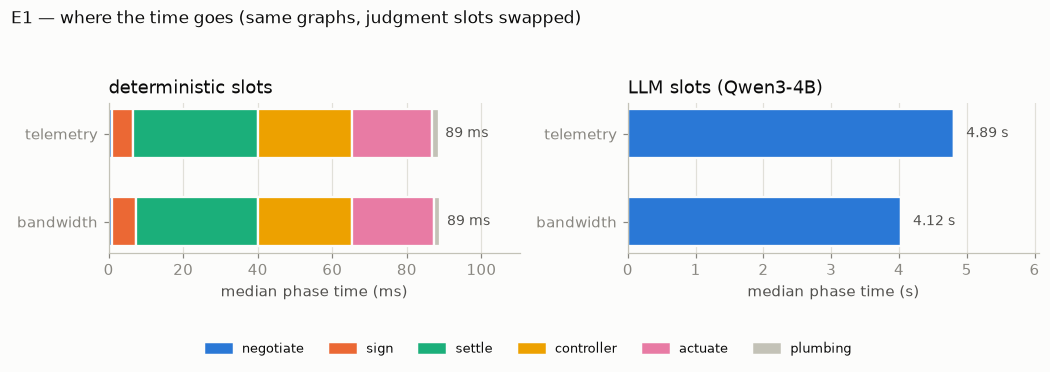

the det→llm delta IS the judgment layer: same nodes, the two model calls added


In [10]:
# E1 — where the time goes. Two panels (ms vs s scales must not share an axis).
SEG = [("negotiate", ["admit_s", "quote_s", "decide_s"], PAL[0]),
       ("sign", ["sign_offer_s", "sign_proof_s"], PAL[1]),
       ("settle", ["settle_s"], PAL[2]),
       ("controller", ["challenge_s", "activate_s"], PAL[3]),
       ("plumbing", ["graph_overhead_s"], INK["other"])]
# 'controller' bundles activate (which contains the gNMI Set); split actuate out:
def seg_ms(mode, svc):
    rs = cell(mode, svc)
    gnmi = med(ph(rs, "gnmi_apply_s")) * 1e3
    out = {}
    for name, keys, _ in SEG:
        out[name] = sum(med(ph(rs, k)) * 1e3 for k in keys if ph(rs, k))
    out["controller"] -= gnmi
    out["actuate"] = gnmi
    return out

order = ["negotiate", "sign", "settle", "controller", "actuate", "plumbing"]
colors = {"negotiate": PAL[0], "sign": PAL[1], "settle": PAL[2],
          "controller": PAL[3], "actuate": PAL[4], "plumbing": INK["other"]}
fig, axes = plt.subplots(1, 2, figsize=(9.6, 2.9), gridspec_kw={"width_ratios": [1, 1]})
for ax, mode, unit in ((axes[0], "det", "ms"), (axes[1], "llm", "s")):
    labels = ["bandwidth", "telemetry"]
    for i, svc in enumerate(labels):
        left = 0.0
        for name in order:
            v = seg_ms(mode, svc)[name] / (1.0 if unit == "ms" else 1e3)
            ax.barh(i, v, left=left, color=colors[name], height=0.55,
                    edgecolor=INK["surface"], linewidth=1.5)
            left += v
        ax.text(left * 1.02, i, f"{left:.0f} {unit}" if unit == "ms" else f"{left:.2f} {unit}",
                va="center", fontsize=9, color=INK["secondary"])
    ax.set_yticks([0, 1], labels)
    ax.set_xlabel(f"median phase time ({unit})")
    ax.set_title("deterministic slots" if mode == "det" else "LLM slots (Qwen3-4B)")
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, ax.get_xlim()[1] * 1.18)
fig.suptitle("E1 — where the time goes (same graphs, judgment slots swapped)",
             x=0.01, ha="left", fontsize=11)
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[n]) for n in order]
fig.legend(handles, order, ncol=6, loc="lower center", bbox_to_anchor=(0.5, -0.14),
           frameon=False, fontsize=8.5)
fig.tight_layout(rect=[0, 0.02, 1, 0.92]); plt.show()
print("the det→llm delta IS the judgment layer: same nodes, the two model calls added")

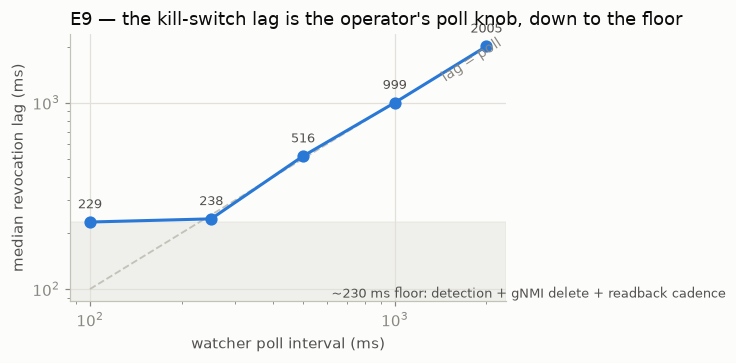

In [11]:
# E9 — revocation lag tracks the poll until the floor takes over
keys_ = sorted(SUMMARY["revlag_sweep"], key=float)
polls = [float(k) for k in keys_]
lags = [SUMMARY["revlag_sweep"][k]["median"] * 1e3 for k in keys_]
fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot([p * 1e3 for p in polls], [p * 1e3 for p in polls], ls="--", lw=1.2,
        color=INK["baseline"], zorder=1)
ax.plot([p * 1e3 for p in polls], lags, marker="o", ms=7, lw=2, color=PAL[0], zorder=3)
for p, l in zip(polls, lags):
    ax.annotate(f"{l:.0f}", (p * 1e3, l), textcoords="offset points", xytext=(0, 9),
                fontsize=8.5, color=INK["secondary"], ha="center")
ax.annotate("lag = poll", (1400, 1300), rotation=33, color=INK["muted"], fontsize=9)
ax.axhspan(0, 230, color=INK["grid"], alpha=0.45, zorder=0)
ax.annotate("~230 ms floor: detection + gNMI delete + readback cadence",
            (620, 90), fontsize=8.5, color=INK["secondary"])
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("watcher poll interval (ms)"); ax.set_ylabel("median revocation lag (ms)")
ax.set_title("E9 — the kill-switch lag is the operator's poll knob, down to the floor")
fig.tight_layout(); plt.show()

## §4.2.2 · Integrity — the adversarial matrix (E4)

Fourteen probes, three defending layers. The contract rejects invalid **money**, the
controller invalid **access**, the provider's admission arithmetic **overselling** — and the
one allowed row *documents* the placement the oversell row *demonstrates*: capacity is
quote-time inventory, not a security predicate.

,probe,layer,code
0,activate before window start,controller,E_NOT_STARTED
1,replay a consumed offer (same salt),contract,OfferAlreadyUsed
2,forged provider signature,contract,BadSignature
3,fulfill a lapsed offer (valid_until past),contract,OfferExpired
4,activation proof signed by a non-owner,controller,E_NOT_OWNER
5,garbage activation signature,controller,E_NOT_OWNER
6,replay a consumed challenge nonce,controller,E_NONCE_REUSED
7,activate the same entitlement twice (double-bo...,controller,E_CONFLICT
8,second entitlement on the same resource,allowed by design,—
9,oversell the resource pool at quote time,provider-admission,insufficient capacity in the requested window


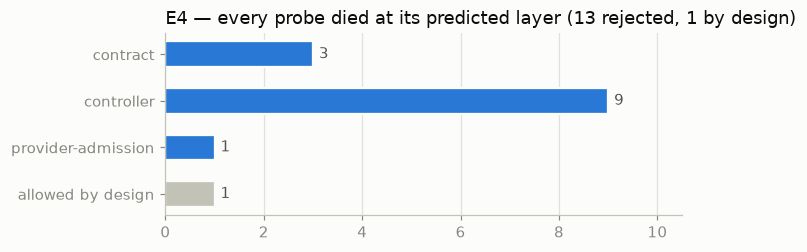

13/13 rejected at the predicted layer with the predicted code; every rejection upstream of any device write


In [12]:
adv = pd.DataFrame([{
    "probe": r["attack"], "layer": r["layer"] or ("allowed by design" if r.get("by_design") else "?"),
    "code": r["code"] or "—"} for r in ADV])
display(adv)
rejected = [r for r in ADV if r["rejected"]]
assert len(ADV) == 14 and len(rejected) == 13
assert all(r["layer"] == r["expected_layer"] for r in rejected if r.get("expected_layer"))
assert sum(1 for r in ADV if r.get("by_design")) == 1
counts = {"contract": 0, "controller": 0, "provider-admission": 0}
for r in rejected: counts[r["layer"]] += 1
fig, ax = plt.subplots(figsize=(6.4, 2.4))
names = list(counts) + ["allowed by design"]
vals = list(counts.values()) + [1]
bars = ax.barh(range(len(names)), vals, height=0.55,
               color=[PAL[0]] * 3 + [INK["other"]], edgecolor=INK["surface"], linewidth=1.5)
for i, v in enumerate(vals):
    ax.text(v + 0.12, i, str(v), va="center", color=INK["secondary"])
ax.set_yticks(range(len(names)), names); ax.invert_yaxis()
ax.grid(axis="y", visible=False); ax.set_xlim(0, 10.5)
ax.set_title("E4 — every probe died at its predicted layer (13 rejected, 1 by design)")
fig.tight_layout(); plt.show()
print("13/13 rejected at the predicted layer with the predicted code; "
      "every rejection upstream of any device write")

## §4.2.3–4 · Cost: latency decomposition, the predicate, gas, judgment (E7, E3, E5, E8)

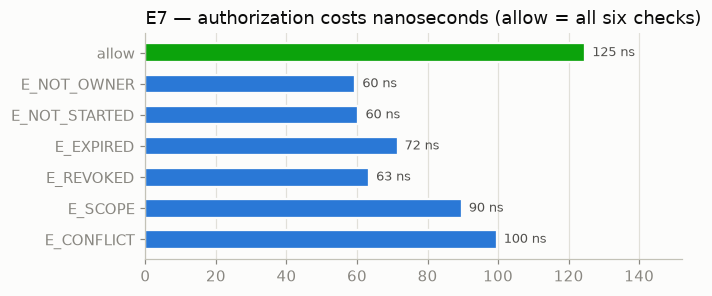

allow 125 ns — four to six orders of magnitude below every phase above;
the deny paths return at the first failing check, so they exit even earlier


In [13]:
# E7 — the six-check predicate, benchmarked in isolation (200k calls per outcome)
pred = SUMMARY["predicate"]
names = list(pred); vals = [pred[n] for n in names]
fig, ax = plt.subplots(figsize=(6.4, 2.8))
colors = [INK["good"] if n == "allow" else PAL[0] for n in names]
ax.barh(range(len(names)), vals, color=colors, height=0.6,
        edgecolor=INK["surface"], linewidth=1.5)
for i, v in enumerate(vals):
    ax.text(v + 2, i, f"{v:.0f} ns", va="center", fontsize=8.5, color=INK["secondary"])
ax.set_yticks(range(len(names)), names); ax.invert_yaxis()
ax.grid(axis="y", visible=False); ax.set_xlim(0, max(vals) * 1.22)
ax.set_title("E7 — authorization costs nanoseconds (allow = all six checks)")
fig.tight_layout(); plt.show()
print(f"allow {pred['allow']:.0f} ns — four to six orders of magnitude below every phase above;")
print("the deny paths return at the first failing check, so they exit even earlier")

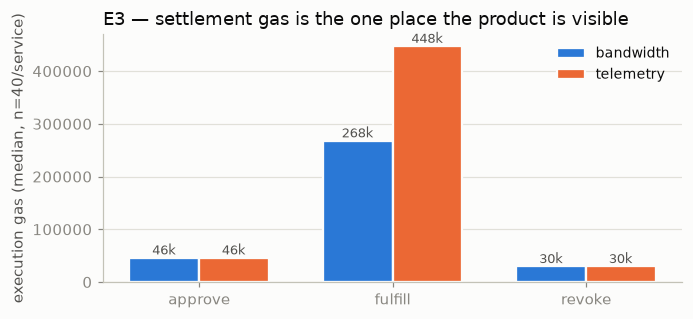

fulfill in dollars (illustrative, ETH $3000):
  bandwidth 268,386 gas → L2 ~$0.024 · L1 ~$6–24
  telemetry 447,719 gas → L2 ~$0.040 · L1 ~$11–40
judgment: ~1115 tokens/negotiation → $0.0002–0.0022


In [14]:
# E3 — gas per call, per service (fulfill is bimodal: telemetry terms are bigger)
gas = SUMMARY["gas"]
ops = ["approve", "fulfill", "revoke"]
bw = [gas["bandwidth"][o]["median"] for o in ops]
tl = [gas["telemetry"][o]["median"] for o in ops]
x = range(len(ops)); w = 0.36
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.bar([i - w/2 for i in x], bw, w, label="bandwidth", color=PAL[0],
       edgecolor=INK["surface"], linewidth=1.5)
ax.bar([i + w/2 for i in x], tl, w, label="telemetry", color=PAL[1],
       edgecolor=INK["surface"], linewidth=1.5)
for i, (b, t) in enumerate(zip(bw, tl)):
    ax.text(i - w/2, b + 6e3, f"{b/1e3:.0f}k", ha="center", fontsize=8.5, color=INK["secondary"])
    ax.text(i + w/2, t + 6e3, f"{t/1e3:.0f}k", ha="center", fontsize=8.5, color=INK["secondary"])
ax.set_xticks(list(x), ops); ax.grid(axis="x", visible=False)
ax.set_ylabel("execution gas (median, n=40/service)")
ax.set_title("E3 — settlement gas is the one place the product is visible")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()
eth, l2, l1a, l1b = 3000, 0.03e-9, 8e-9, 30e-9
f_bw, f_tl = gas["bandwidth"]["fulfill"]["median"], gas["telemetry"]["fulfill"]["median"]
print(f"fulfill in dollars (illustrative, ETH ${eth}):")
print(f"  bandwidth {f_bw:,.0f} gas → L2 ~${f_bw*l2*eth:.3f} · L1 ~${f_bw*l1a*eth:.0f}–{f_bw*l1b*eth:.0f}")
print(f"  telemetry {f_tl:,.0f} gas → L2 ~${f_tl*l2*eth:.3f} · L1 ~${f_tl*l1a*eth:.0f}–{f_tl*l1b*eth:.0f}")
cpn = SUMMARY["llm"]["cost_per_negotiation"]
print(f"judgment: ~{cpn['total_tokens_median']:.0f} tokens/negotiation → "
      f"${cpn['usd_at_0.20_per_Mtok']:.4f}–{cpn['usd_at_2.00_per_Mtok']:.4f}")

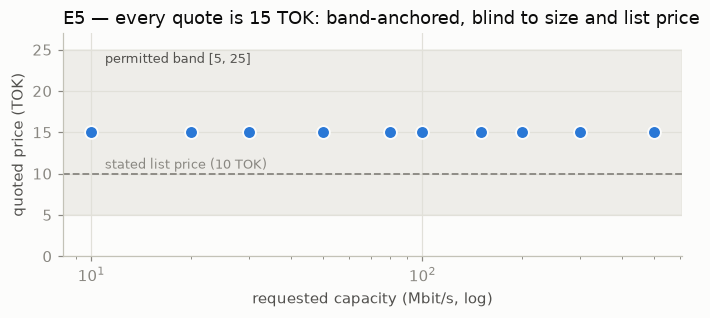

quote:  10/10 schema-valid first attempt, all in band, values [15]
decide: 12/12 vs accept-iff-affordable ground truth (9/9 off-boundary)
no price discovery — the slot echoes its prompt's band midpoint; stated as a finding,
not hidden (under the older list-price-in-system-prompt framing it anchored at 10)


In [15]:
# E5 — the judgment slots, reported against interest: the quote anchors on the band
q = [r for r in LLM if r["slot"] == "quote"]
d = [r for r in LLM if r["slot"] == "decide"]
caps = [int(r["case"].replace("mbps", "")) for r in q]
quotes = [r["quoted"] for r in q]
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.axhspan(5, 25, color=INK["grid"], alpha=0.5, zorder=0)
ax.axhline(10, ls="--", lw=1.2, color=INK["muted"], zorder=1)
ax.annotate("permitted band [5, 25]", (11, 23.4), fontsize=8.5, color=INK["secondary"])
ax.annotate("stated list price (10 TOK)", (11, 10.6), fontsize=8.5, color=INK["muted"])
ax.scatter(caps, quotes, s=70, color=PAL[0], zorder=3, edgecolor=INK["surface"], linewidth=1.2)
ax.set_xscale("log")
ax.set_xlabel("requested capacity (Mbit/s, log)"); ax.set_ylabel("quoted price (TOK)")
ax.set_ylim(0, 27)
ax.set_title("E5 — every quote is 15 TOK: band-anchored, blind to size and list price")
fig.tight_layout(); plt.show()
graded = [r for r in d if r["ok"]]
print(f"quote:  {sum(r['ok'] for r in q)}/10 schema-valid first attempt, all in band, "
      f"values {sorted(set(quotes))}")
print(f"decide: {sum(r['correct'] for r in graded)}/12 vs accept-iff-affordable ground truth "
      f"({sum(r['correct'] for r in graded if not r.get('boundary'))}/9 off-boundary)")
print("no price discovery — the slot echoes its prompt's band midpoint; stated as a finding,")
print("not hidden (under the older list-price-in-system-prompt framing it anchored at 10)")

## §4.2.5 · Service invariance — the headline (RQ2)

Forty telemetry lifecycles ran through the *same contract, same agent graphs, same
custodians, same challenge–response, same predicate* as the forty bandwidth ones. The
shared machinery tracks within a few milliseconds; the judgment slots may differ (longer
telemetry JSON = more prompt); the **only** product trace is settlement gas — the byte-size
of the stored terms.

In [16]:
keys = [("admit_s", "admit"), ("sign_offer_s", "sign offer"), ("decide_s", "decide"),
        ("settle_s", "settle"), ("challenge_s", "challenge"), ("sign_proof_s", "sign proof"),
        ("activate_s", "activate"), ("gnmi_apply_s", "gNMI apply"),
        ("verify_readback_s", "readback")]
deltas = []
for k, label in keys:
    b = med(ph(cell("det", "bandwidth"), k)) * 1e3
    t = med(ph(cell("det", "telemetry"), k)) * 1e3
    deltas.append((label, b, t, abs(b - t)))
inv = pd.DataFrame(deltas, columns=["phase", "bandwidth (ms)", "telemetry (ms)", "|Δ| (ms)"])
display(inv.round(2))
worst = inv["|Δ| (ms)"].max()
print(f"largest shared-phase gap: {worst:.1f} ms — same machinery executing, not similar machinery")
assert worst < 5, "invariance margin blew past a few milliseconds"

,phase,bandwidth (ms),telemetry (ms),|Δ| (ms)
0,admit,0.63,0.59,0.04
1,sign offer,3.12,3.06,0.06
2,decide,0.24,0.24,0.00
3,settle,32.72,33.63,0.91
4,challenge,9.80,9.63,0.17
5,sign proof,3.20,2.39,0.82
6,activate,37.27,36.92,0.35
7,gNMI apply,21.95,21.22,0.72
8,readback,16.61,18.85,2.24


largest shared-phase gap: 2.2 ms — same machinery executing, not similar machinery


## §5 · Conclusions — recomputed, or this cell fails

Each headline claim of the paper, derived from the raw JSONL right now. If the data and
the prose ever drift, the asserts below break the build.

In [17]:
det_ms = med([r["phases"]["e2e_request_to_enforced_s"] for r in OK if r["mode"] == "det"]) * 1e3
llm_s = med([r["phases"]["e2e_request_to_enforced_s"] for r in OK if r["mode"] == "llm"])
rev_ms = med(ph(OK, "revocation_lag_s")) * 1e3
exp_ms = med([r["tick_to_deconfig_s"] for r in EXP if r["ok"]]) * 1e3
f_bw = SUMMARY["gas"]["bandwidth"]["fulfill"]["median"]
f_tl = SUMMARY["gas"]["telemetry"]["fulfill"]["median"]

print(f"1. feasibility  : 80/80 autonomous lifecycles; det {det_ms:.0f} ms / LLM {llm_s:.2f} s end to end")
print(f"2. integrity    : 13/14 probes rejected at the predicted layer; 1 allowed by design;")
print(f"                  overselling refused at provider admission, measured")
print(f"3. enforcement  : expiry {exp_ms:.0f} ms; revocation {rev_ms:.0f} ms @0.5 s poll (the entitlement governs the wire)")
print(f"4. cost         : fulfill {f_bw/1e3:.0f}k/{f_tl/1e3:.0f}k gas (cents on a rollup); predicate {SUMMARY['predicate']['allow']:.0f} ns;")
print(f"                  ~{SUMMARY['llm']['cost_per_negotiation']['total_tokens_median']:.0f} tokens (<1¢) per negotiation")
print(f"5. invariance   : one translator + one catalogue row + term byte-size — nothing else changed")

assert sum(r["ok"] for r in LAT) == 80 and len(LAT) == 80
assert abs(det_ms - 89) < 4, det_ms          # the paper says 89 ms
assert 4.0 < llm_s < 5.2, llm_s              # the paper says 4.66 s
assert abs(exp_ms - 75) < 4 and 350 < rev_ms < 520
assert len(ADV) == 14 and sum(r["rejected"] for r in ADV) == 13
assert abs(f_bw - 268_386) < 2_000 and abs(f_tl - 447_719) < 2_000
print("\nall paper headlines reproduced from raw data ✓")

1. feasibility  : 80/80 autonomous lifecycles; det 89 ms / LLM 4.66 s end to end
2. integrity    : 13/14 probes rejected at the predicted layer; 1 allowed by design;
                  overselling refused at provider admission, measured
3. enforcement  : expiry 75 ms; revocation 440 ms @0.5 s poll (the entitlement governs the wire)
4. cost         : fulfill 268k/448k gas (cents on a rollup); predicate 125 ns;
                  ~1115 tokens (<1¢) per negotiation
5. invariance   : one translator + one catalogue row + term byte-size — nothing else changed

all paper headlines reproduced from raw data ✓


---
### Boundaries, stated plainly (paper §4.2.9)

In-process transport (A2A = loopback codec; controller app via in-process client) ·
zero-delay local chain (compute-only lower bounds; consensus extrapolated) · enforcement =
config committed **and read back**, datapath proof once via the documented shim ·
n=20 warm sequential (medians, no tails) · one model, one deployment, curated probes.

### Pointers
Prose ground truth **`docs/09-evaluation.md`** · demo console **`just console`**
(the six steps as a live control room) · dataset `e2e/runs/eval/` (committed) ·
paper source `Paper-A2ATokenizedSmartContracts/main.tex`.